# Description

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV495"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv495')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv495/lv495-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV495,gene_band
0,PAPD7,6.237510,5p15.31
1,MSN,5.188465,NaN
2,STRAP,4.847822,12p12.3
3,TXNDC12,4.780548,1p32.3
4,DERL1,3.980530,8q24.13
5,UBE2Q1,3.592996,1q21.3
6,CTNND1,3.500222,11q12.1
7,MCCC1,3.103495,3q27.1
8,ALS2,2.982951,2q33.1
9,SLC36A1,2.957961,5q33.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-01-29 20:36:53,741 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-01-29 20:36:53,741 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057205, SRP055569, SRP060416, SRP012461, SRP003901, SRP018525, SRP024268, SRP066834, SRP057196, SRP015976, SRP002326, SRP042161, SRP034666, SRP033135, SRP007947, SRP023111, SRP050499, SRP055153, SRP050892, SRP042218, SRP059379, SRP058773, SRP064464, SRP059775, SRP011546, SRP059039, SRP009266, SRP064259, SRP067214, SRP056084, SRP022892, SRP007569, SRP018861, SRP058856, SRP055810, SRP059950, SRP041826, SRP033466, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (37 != 38)
  warnings.warn(


In [12]:
lv_data.shape

(6146, 75)

In [13]:
lv_data.head()

cell line gfp cd13 ssea4 tra160 cell type  \
project   run                                                       
SRP057205 SRR1975508  Detroit 551  NA   NA    NA     NA       NaN   
          SRR1975507  Detroit 551  NA   NA    NA     NA       NaN   
          SRR1975506  Detroit 551  NA   NA    NA     NA       NaN   
          SRR1975505  Detroit 551  NA   NA    NA     NA       NaN   
          SRR1975503  Detroit 551   -   NA     +      +       NaN   

                     tonsil donor facs gating treatment  day  ...  \
project   run                                                 ...   
SRP057205 SRR1975508          NaN         NaN       NaN  NaN  ...   
          SRR1975507          NaN         NaN       NaN  NaN  ...   
          SRR1975506          NaN         NaN       NaN  NaN  ...   
          SRR1975505          NaN         NaN       NaN  NaN  ...   
          SRR1975503          NaN         NaN       NaN  NaN  ...   

                     mice generation tumor treatment stage xenograft host  \
project   run                                                               
SRP057205 SRR1975508             NaN                   NaN            NaN   
          SRR1975507             NaN                   NaN            NaN   
          SRR1975506             NaN                   NaN            NaN   
          SRR1975505             NaN                   NaN            NaN   
          SRR1975503             NaN                   NaN            NaN   

                     timepoint agent donor ectopic expression genotype  \
project   run                                                            
SRP057205 SRR1975508       NaN   NaN   NaN                NaN      NaN   
          SRR1975507       NaN   NaN   NaN                NaN      NaN   
          SRR1975506       NaN   NaN   NaN                NaN      NaN   
          SRR1975505       NaN   NaN   NaN                NaN      NaN   
          SRR1975503       NaN   NaN   NaN                NaN      NaN   

                     p/i stimulation     LV495  
project   run                                   
SRP057205 SRR1975508             NaN  0.023053  
          SRR1975507             NaN  0.022539  
          SRR1975506             NaN  0.016007  
          SRR1975505             NaN  0.018119  
          SRR1975503             NaN  0.156572  

[5 rows x 75 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

gfp                       2.109309
cd13                      2.109309
ssea4                     2.109309
tra160                    2.109309
cell line                 0.168328
overexpression            0.016058
ethnicity                 0.008744
supplementary file        0.008744
tnm                       0.008086
culture medium            0.006409
transfected with          0.006317
antibody                  0.004322
facs gating               0.003371
tonsil donor              0.003371
c1 chip id                0.002941
experiment_sample_name    0.002941
passages                  0.002478
ip antibody               0.002478
cell type                 0.002389
cancer or normal          0.002388
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line    0.168328
cell type    0.002389
tissue       0.002254
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell line",
    "cell type",
    "tissue",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell line  \
project   run                       
SRP057205 SRR1975497  Detroit 551   
          SRR1975498  Detroit 551   
          SRR1975502  Detroit 551   
          SRR1975501  Detroit 551   
          SRR1975496  Detroit 551   
          SRR1975495  Detroit 551   
          SRR1975482  Detroit 551   
          SRR1975481  Detroit 551   
          SRR1975453  Detroit 551   
          SRR1975454  Detroit 551   
          SRR1975471  Detroit 551   
          SRR1975472  Detroit 551   
SRP055569 SRR1821572          NaN   
SRP060416 SRR2088209          NaN   
SRP057205 SRR1975464           H1   
          SRR1975463           H1   
SRP012461 SRR490310           NaN   
SRP003901 SRR070179           NaN   
SRP057205 SRR1975483  Detroit 551   
          SRR1975484  Detroit 551   
          SRR1975458  Detroit 551   
          SRR1975457  Detroit 551   
SRP018525 SRR893046           NaN   
SRP055569 SRR1821646          NaN   
SRP057205 SRR1975455  Detroit 551   

                                                              cell type  \
project   run                                                             
SRP057205 SRR1975497                                                NaN   
          SRR1975498                                                NaN   
          SRR1975502                                                NaN   
          SRR1975501                                                NaN   
          SRR1975496                                                NaN   
          SRR1975495                                                NaN   
          SRR1975482                                                NaN   
          SRR1975481                                                NaN   
          SRR1975453                                                NaN   
          SRR1975454                                                NaN   
          SRR1975471                                                NaN   
          SRR1975472                                                NaN   
SRP055569 SRR1821572  mixture of U87 human glioma cells and MCF10a h...   
SRP060416 SRR2088209                       tonsil Innate lymphoid cells   
SRP057205 SRR1975464                                                NaN   
          SRR1975463                                                NaN   
SRP012461 SRR490310                              Mesenchymal Stem Cells   
SRP003901 SRR070179                                                 NaN   
SRP057205 SRR1975483                                                NaN   
          SRR1975484                                                NaN   
          SRR1975458                                                NaN   
          SRR1975457                                                NaN   
SRP018525 SRR893046                                              oocyte   
SRP055569 SRR1821646                   MCF10a human breast cancer cells   
SRP057205 SRR1975455                                                NaN   

                             tissue     LV495  
project   run                                  
SRP057205 SRR1975497            NaN  7.908685  
          SRR1975498            NaN  7.883051  
          SRR1975502            NaN  1.027488  
          SRR1975501            NaN  1.025953  
          SRR1975496            NaN  0.982759  
          SRR1975495            NaN  0.977646  
          SRR1975482            NaN  0.808831  
          SRR1975481            NaN  0.808687  
          SRR1975453            NaN  0.730280  
          SRR1975454            NaN  0.729028  
          SRR1975471            NaN  0.699565  
          SRR1975472            NaN  0.698062  
SRP055569 SRR1821572            NaN  0.593791  
SRP060416 SRR2088209            NaN  0.532575  
SRP057205 SRR1975464            NaN  0.532322  
          SRR1975463            NaN  0.531715  
SRP012461 SRR490310             NaN  0.509663  
SRP003901 SRR070179   kidney normal  0.400589  
SRP057205 SRR1975483            NaN  0

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

cell line  \
project   run                                       
SRP057205 SRR1975456                  Detroit 551   
SRP060416 SRR2088252                          NaN   
SRP055569 SRR2018982                          NaN   
SRP024268 SRR886370                           NaN   
SRP057205 SRR1975493                  Detroit 551   
          SRR1975494                  Detroit 551   
SRP055569 SRR2018972                          NaN   
SRP066834 SRR2967692                          NaN   
SRP057196 SRR1974601                          NaN   
SRP055569 SRR2019062                          NaN   
SRP015976 SRR578826                           NaN   
SRP057196 SRR1974874                          NaN   
SRP002326 SRR040017                           NaN   
SRP057205 SRR1975492                  Detroit 551   
          SRR1975491                  Detroit 551   
          SRR1975478                  Detroit 551   
          SRR1975477                  Detroit 551   
SRP042161 SRR1294652                          NaN   
SRP055569 SRR2019134                          NaN   
SRP066834 SRR2967292                          NaN   
SRP018525 SRR893053                           NaN   
SRP055569 SRR1821533                          NaN   
SRP034666 SRR1056281  osteosarcoma U2OS cell line   
SRP055569 SRR1821413                          NaN   
SRP057205 SRR1975470                  Detroit 551   

                                                              cell type  \
project   run                                                             
SRP057205 SRR1975456                                                NaN   
SRP060416 SRR2088252                       tonsil Innate lymphoid cells   
SRP055569 SRR2018982  mixture of U87 human glioma cells and MCF10a h...   
SRP024268 SRR886370                                                 NaN   
SRP057205 SRR1975493                                                NaN   
          SRR1975494                                                NaN   
SRP055569 SRR2018972  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967692                                                NaN   
SRP057196 SRR1974601                                             hybrid   
SRP055569 SRR2019062                             U87 human glioma cells   
SRP015976 SRR578826                                   HEK293 cell lines   
SRP057196 SRR1974874                                         astrocytes   
SRP002326 SRR040017                                                 NaN   
SRP057205 SRR1975492                                                NaN   
          SRR1975491                                                NaN   
          SRR1975478                                                NaN   
          SRR1975477                                                NaN   
SRP042161 SRR1294652                                       Glioblastoma   
SRP055569 SRR2019134  mixture of U87 human glioma cells and WI-38 hu...   
SRP066834 SRR2967292                                                NaN   
SRP018525 SRR893053                                              zygote   
SRP055569 SRR1821533  mixture of U87 human glioma cells and MCF10a h...   
SRP034666 SRR1056281                                                NaN   
SRP055569 SRR1821413  mixture of U87 human glioma cells and MCF10a h...   
SRP057205 SRR1975470                                                NaN   

                                                   tissue     LV495  
project   run                                                        
SRP057205 SRR1975456                                  NaN  0.334599  
SRP060416 SRR2088252                                  NaN  0.319674  
SRP055569 SRR2018982                                  NaN  0.312643  
SRP024268 SRR886370                          renal pelvis  0.303865  
SRP057205 SRR1975493                                  NaN  0.303466  
          SRR1975494                                  NaN  0.303263  
SRP055569 SRR2018972  

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [ ]:
# list the top 10 samples from this project
lv_data.loc[["SRP015360"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [21]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "cell type",
    "tissue",
]

## Get a single attribute with "cell type/tissue" information

In [22]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [23]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [24]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [25]:
plot_data.head(20)

cell line  \
project   run                                                             
SRP057205 SRR1975497                                        Detroit 551   
          SRR1975498                                        Detroit 551   
          SRR1975502                                        Detroit 551   
          SRR1975501                                        Detroit 551   
          SRR1975496                                        Detroit 551   
          SRR1975495                                        Detroit 551   
          SRR1975482                                        Detroit 551   
          SRR1975481                                        Detroit 551   
          SRR1975453                                        Detroit 551   
          SRR1975454                                        Detroit 551   
          SRR1975471                                        Detroit 551   
          SRR1975472                                        Detroit 551   
SRP055569 SRR1821572  mixture of U87 human glioma cells and MCF10a h...   
SRP060416 SRR2088209                       tonsil Innate lymphoid cells   
SRP057205 SRR1975464                                                 H1   
          SRR1975463                                                 H1   
SRP012461 SRR490310                              Mesenchymal Stem Cells   
SRP003901 SRR070179                                       kidney normal   
SRP057205 SRR1975483                                        Detroit 551   
          SRR1975484                                        Detroit 551   

                         LV495  
project   run                   
SRP057205 SRR1975497  7.908685  
          SRR1975498  7.883051  
          SRR1975502  1.027488  
          SRR1975501  1.025953  
          SRR1975496  0.982759  
          SRR1975495  0.977646  
          SRR1975482  0.808831  
          SRR1975481  0.808687  
          SRR1975453  0.730280  
          SRR1975454  0.729028  
          SRR1975471  0.699565  
          SRR1975472  0.698062  
SRP055569 SRR1821572  0.593791  
SRP060416 SRR2088209  0.532575  
SRP057205 SRR1975464  0.532322  
          SRR1975463  0.531715  
SRP012461 SRR490310   0.509663  
SRP003901 SRR070179   0.400589  
SRP057205 SRR1975483  0.390928  
          SRR1975484  0.390452

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [26]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [27]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [28]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [29]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [30]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [31]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [32]:
N_TOP_ATTRS = 10

In [33]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [34]:
len(attr_order)

10

In [35]:
attr_order[:5]

['Detroit 551',
 'mixture of U87 human glioma cells and MCF10a human breast cancer cells',
 'tonsil Innate lymphoid cells',
 'H1',
 'Mesenchymal Stem Cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

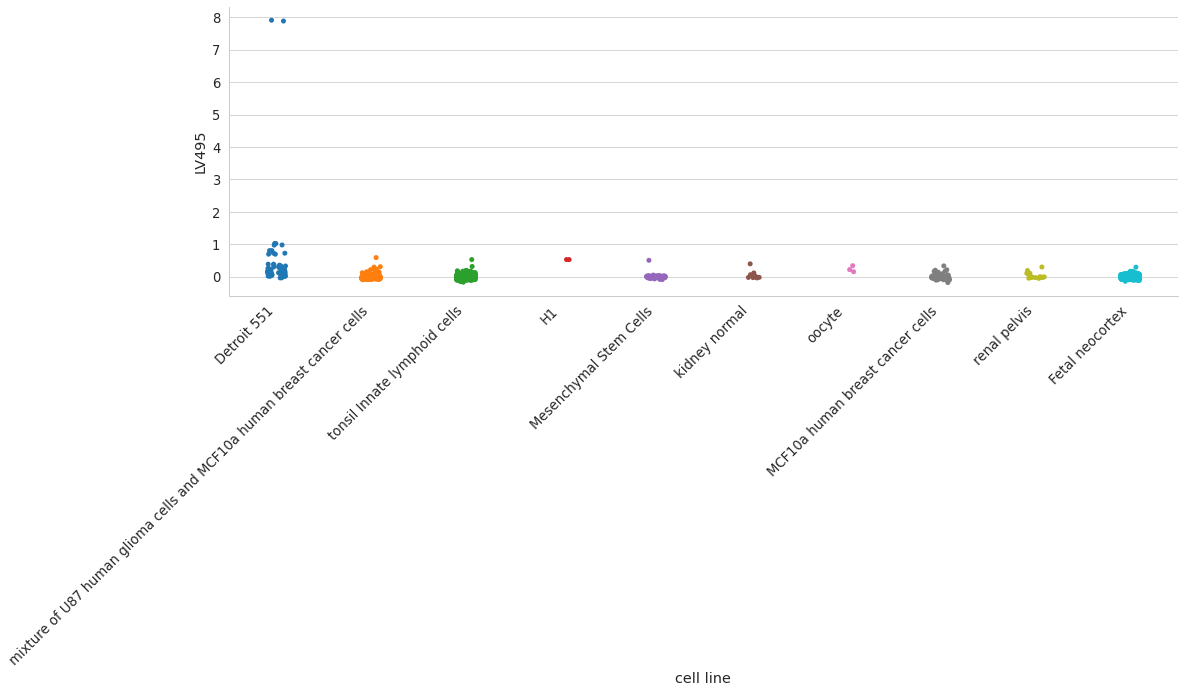

In [36]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [39]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Detroit")
    ]
    display(_tmp.head(20))

cell line     LV495
project   run                              
SRP057205 SRR1975497  Detroit 551  7.908685
          SRR1975498  Detroit 551  7.883051
          SRR1975502  Detroit 551  1.027488
          SRR1975501  Detroit 551  1.025953
          SRR1975496  Detroit 551  0.982759
          SRR1975495  Detroit 551  0.977646
          SRR1975482  Detroit 551  0.808831
          SRR1975481  Detroit 551  0.808687
          SRR1975453  Detroit 551  0.730280
          SRR1975454  Detroit 551  0.729028
          SRR1975471  Detroit 551  0.699565
          SRR1975472  Detroit 551  0.698062
          SRR1975483  Detroit 551  0.390928
          SRR1975484  Detroit 551  0.390452
          SRR1975458  Detroit 551  0.359700
          SRR1975457  Detroit 551  0.359448
          SRR1975455  Detroit 551  0.334715
          SRR1975456  Detroit 551  0.334599
          SRR1975493  Detroit 551  0.303466
          SRR1975494  Detroit 551  0.303263

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [40]:
# what is there in these projects?
lv_data.loc[["SRP057205"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line gfp cd13 ssea4 tra160     LV495
project   run                                                    
SRP057205 SRR1975497  Detroit 551   +   NA     +      -  7.908685
          SRR1975498  Detroit 551   +   NA     +      -  7.883051
          SRR1975502  Detroit 551   -   NA     +      +  1.027488
          SRR1975501  Detroit 551   -   NA     +      +  1.025953
          SRR1975496  Detroit 551   +   NA     -      -  0.982759
          SRR1975495  Detroit 551   +   NA     -      -  0.977646
          SRR1975482  Detroit 551   +    -     +     NA  0.808831
          SRR1975481  Detroit 551   +    -     +     NA  0.808687
          SRR1975453  Detroit 551  NA   NA    NA     NA  0.730280
          SRR1975454  Detroit 551  NA   NA    NA     NA  0.729028
          SRR1975471  Detroit 551   +    +    NA     NA  0.699565
          SRR1975472  Detroit 551   +    +    NA     NA  0.698062
          SRR1975464           H1  NA   NA    NA     NA  0.532322
          SRR1975463           H1  NA   NA    NA     NA  0.531715
          SRR1975483  Detroit 551   -    -     +     NA  0.390928
          SRR1975484  Detroit 551   -    -     +     NA  0.390452
          SRR1975458  Detroit 551  NA   NA    NA     NA  0.359700
          SRR1975457  Detroit 551  NA   NA    NA     NA  0.359448
          SRR1975455  Detroit 551  NA   NA    NA     NA  0.334715
          SRR1975456  Detroit 551  NA   NA    NA     NA  0.334599
          SRR1975493  Detroit 551   -   NA     +      +  0.303466
          SRR1975494  Detroit 551   -   NA     +      +  0.303263
          SRR1975492  Detroit 551   -   NA     +      +  0.261280
          SRR1975491  Detroit 551   -   NA     +      +  0.260522
          SRR1975478  Detroit 551   +    +     -     NA  0.257926
          SRR1975477  Detroit 551   +    +     -     NA  0.257492
          SRR1975470  Detroit 551   +    -    NA     NA  0.223823
          SRR1975469  Detroit 551   +    -    NA     NA  0.223620
          SRR1975465           H9  NA   NA    NA     NA  0.163754
          SRR1975466           H9  NA   NA    NA     NA  0.163748
          SRR1975474  Detroit 551   +    +    NA     NA  0.162109
          SRR1975473  Detroit 551   +    +    NA     NA  0.161727
          SRR1975504  Detroit 551   -   NA     +      +  0.158807
          SRR1975503  Detroit 551   -   NA     +      +  0.156572
          SRR1975487  Detroit 551   -   NA     +      -  0.154132
          SRR1975488  Detroit 551   -   NA     +      -  0.153520
          SRR1975459  Detroit 551  NA   NA    NA     NA  0.126605
          SRR1975460  Detroit 551  NA   NA    NA     NA  0.125998
          SRR1975461  Detroit 551  NA   NA    NA     NA  0.116095
          SRR1975462  Detroit 551  NA   NA    NA     NA  0.116004
          SRR1975499  Detroit 551   -   NA     +      -  0.105964
          SRR1975500  Detroit 551   -   NA     +      -  0.105950
          SRR1975475  Detroit 551   +    -     -     NA  0.076525
          SRR1975476  Detroit 551   +    -     -     NA  0.074444
          SRR1975490  Detroit 551   +   NA     +      -  0.072696
          SRR1975489  Detroit 551   +   NA     +      -  0.072185
          SRR1975485  Detroit 551   +   NA     -      -  0.043783
          SRR1975486  Detroit 551   +   NA     -      -  0.042114
          SRR1975508  Detroit 551  NA   NA    NA     NA  0.023053
          SRR1975507  Detroit 551  NA   NA    NA     NA  0.022539
          SRR1975505  Detroit 551  NA   NA    NA     NA  0.018119
          SRR1975506  Detroit 551  NA   NA    NA     NA  0.016007
          SRR1975468         PGP1  NA   NA    NA     NA  0.009392
          SRR1975467         PGP1  NA   NA    NA     NA  0.009392
          SRR1975479  Detroit 551   +    +     +     NA -0.031018
          SRR1975480  Detroit 551   +    +     +     NA -0.032075

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.